[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Колонки датасету: Index(['review', 'sentiment'], dtype='object')

Перші 5 рядків:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Лемматизація

Приклад після передобробки:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                     lemmatized_text  
0  one reviewers mentioned watching 1 oz episode ...  
1  wonderful little production br br filming tech

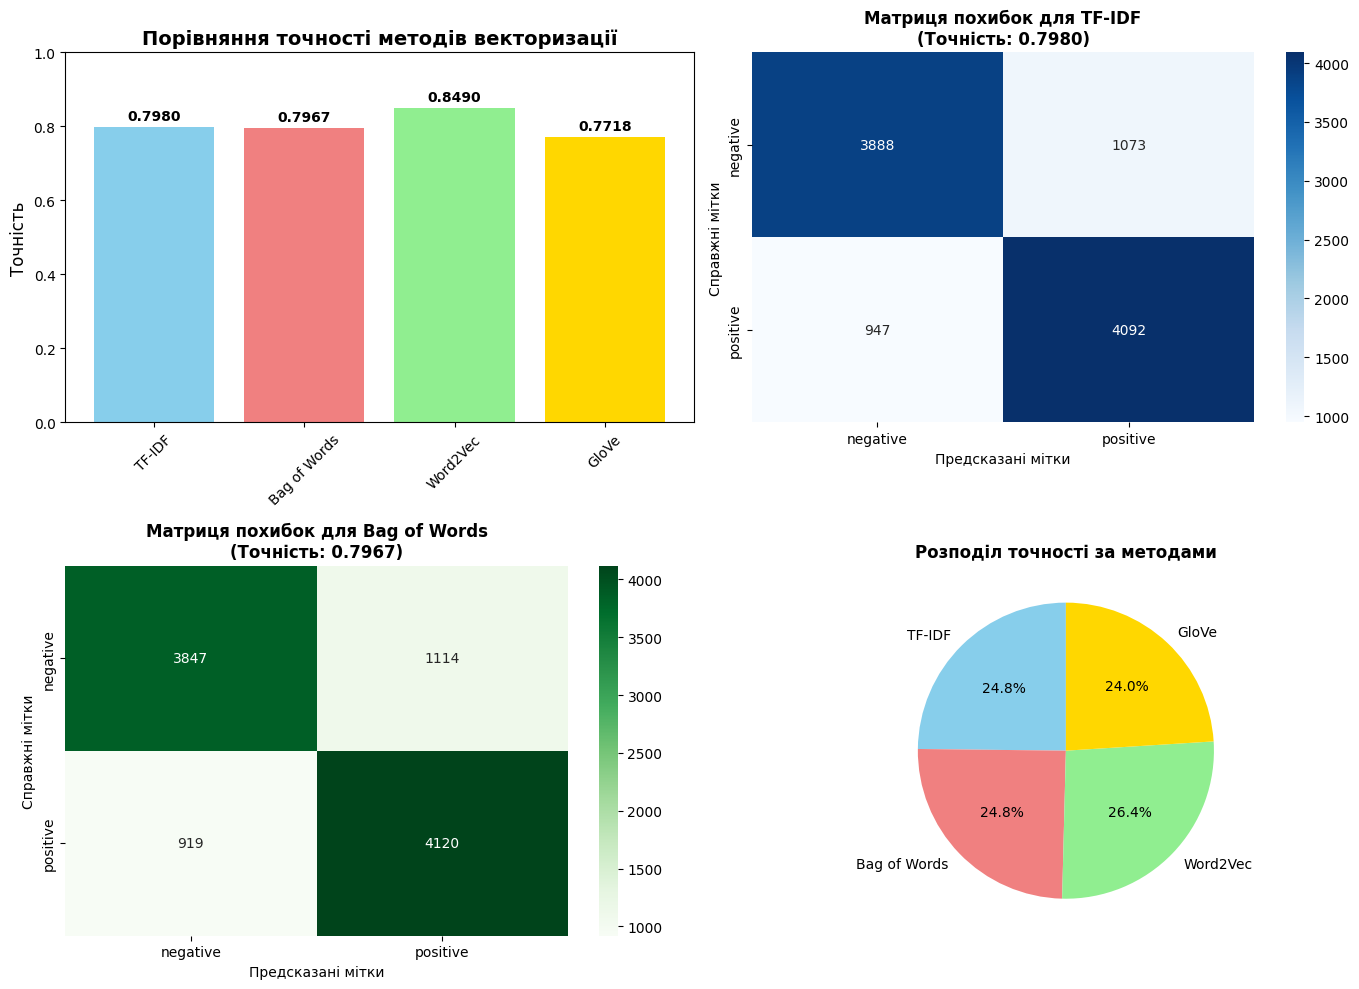


Найкращий метод: Word2Vec з точністю - 0.8490

Приклади передбачень для TF-IDF

Текст: I consider myself a bit of a connoisseur of boxing movies and as such there is only one thing that p
Справжня мітка: positive
Передбачена мітка: negative

Текст: Robert Altman's downbeat, new-fangled western from Edmund Naughton's book "McCabe" was overlooked at
Справжня мітка: positive
Передбачена мітка: positive

Текст: Finally! An Iranian film that is not made by Majidi, Kiarostami or the Makhmalbafs. This is a non-do
Справжня мітка: negative
Передбачена мітка: negative

Текст: I saw Brother's Shadow at the Tribeca Film Festival and loved it! Judd Hirsch and Scott Cohen are gr
Справжня мітка: positive
Передбачена мітка: positive

Текст: Perhaps the most gripping and intelligent of crooked cop movies is Otto Preminger's 'Where the Sidew
Справжня мітка: negative
Передбачена мітка: negative


Статистика даних

Загальна кількість відгуків: 50000

Розподіл міток: {'positive': 25000, 'negative': 25000}

In [ ]:


import pandas as pd
import re
import nltk
import spacy
import numpy as np
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
import gensim.downloader as api


nltk.download('stopwords')


try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")


data = pd.read_csv("laba12.csv")
print("\nКолонки датасету:", data.columns)
print("\nПерші 5 рядків:")
print(data.head())


data['review'] = data['review'].fillna('')
data['sentiment'] = data['sentiment'].fillna('')


data['cleaned_text'] = data['review'].apply(lambda x: re.sub(r'[^\w\s]', '', str(x).lower()))


data['cleaned_text'] = data['cleaned_text'].apply(lambda x: x[:1000])


stop_words = set(stopwords.words('english'))
data['cleaned_text'] = data['cleaned_text'].apply(
    lambda x: ' '.join(word for word in x.split() if word not in stop_words)
)


print("\nЛемматизація")
with nlp.select_pipes(disable=["tagger", "parser", "ner"]):
    data['lemmatized_text'] = [
        ' '.join([token.lemma_ for token in doc])
        for doc in nlp.pipe(
            data['cleaned_text'],
            batch_size=100,
            n_process=4
        )
    ]


data['tokenized_text'] = data['lemmatized_text'].apply(lambda x: x.split())

print("\nПриклад після передобробки:")
print(data[['review', 'lemmatized_text']].head())


def document_vector(tokens, model, dimension):
    vectors = []
    for token in tokens:
        if token in model:
            vectors.append(model[token])
    
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(dimension)


def train_and_evaluate(X, y, method_name, method_type="count"):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    if method_type == "count":
        
        model = MultinomialNB()
    else:
        
        model = LogisticRegression(random_state=42, max_iter=1000)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"{method_name} точність: {accuracy:.4f}")
    return accuracy, X_train, X_test, y_train, y_test, y_pred, model


results = {}


print("\nTF-IDF векторизація")

vectorizer_tfidf = TfidfVectorizer(max_features=500)
X_tfidf = vectorizer_tfidf.fit_transform(data['lemmatized_text'])
accuracy_tfidf, X_train_tf, X_test_tf, y_train_tf, y_test_tf, y_pred_tf, model_tf = train_and_evaluate(
    X_tfidf, data['sentiment'], "TF-IDF", "count")
results['TF-IDF'] = accuracy_tfidf


print("\nBag of Words векторизація")

vectorizer_bow = CountVectorizer(max_features=500)
X_bow = vectorizer_bow.fit_transform(data['lemmatized_text'])
accuracy_bow, X_train_bow, X_test_bow, y_train_bow, y_test_bow, y_pred_bow, model_bow = train_and_evaluate(
    X_bow, data['sentiment'], "Bag of Words", "count")
results['Bag of Words'] = accuracy_bow



print("\nWord2Vec векторизація")


print("Навчання Word2Vec моделі")
w2v_model = Word2Vec(
    sentences=data['tokenized_text'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1 
)


print("Створення Word2Vec векторів")
X_w2v = np.array([document_vector(tokens, w2v_model.wv, 100) for tokens in data['tokenized_text']])

accuracy_w2v, X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v, y_pred_w2v, model_w2v = train_and_evaluate(
    X_w2v, data['sentiment'], "Word2Vec", "embedding")
results['Word2Vec'] = accuracy_w2v


print("\nGloVe векторизація")


try:
    print("Завантаження GloVe моделі")
  
    glove_vectors = api.load("glove-wiki-gigaword-100")
    
    print("Створення GloVe векторів")
    X_glove = np.array([document_vector(tokens, glove_vectors, 100) for tokens in data['tokenized_text']])
    
    accuracy_glove, X_train_gl, X_test_gl, y_train_gl, y_test_gl, y_pred_gl, model_gl = train_and_evaluate(
        X_glove, data['sentiment'], "GloVe", "embedding")
    results['GloVe'] = accuracy_glove

except Exception as e:
    print(f"Помилка завантаження GloVe: {e}")
    print("Використання Word2Vec як заміна для GloVe")
    results['GloVe'] = accuracy_w2v  



results_df = pd.DataFrame(list(results.items()), columns=['Метод', 'Точність'])
print("\nТаблиця результатів:")
print(results_df)


plt.figure(figsize=(14, 10))


plt.subplot(2, 2, 1)
methods = list(results.keys())
accuracies = list(results.values())
bars = plt.bar(methods, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Порівняння точності методів векторизації', fontsize=14, fontweight='bold')
plt.ylabel('Точність', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1)


for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')


plt.subplot(2, 2, 2)
cm_tfidf = confusion_matrix(y_test_tf, y_pred_tf)
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_tf.classes_, 
            yticklabels=model_tf.classes_)
plt.title(f'Матриця похибок для TF-IDF\n(Точність: {accuracy_tfidf:.4f})', fontweight='bold')
plt.ylabel('Справжні мітки')
plt.xlabel('Предсказані мітки')


plt.subplot(2, 2, 3)
cm_bow = confusion_matrix(y_test_bow, y_pred_bow)
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Greens',
            xticklabels=model_bow.classes_, 
            yticklabels=model_bow.classes_)
plt.title(f'Матриця похибок для Bag of Words\n(Точність: {accuracy_bow:.4f})', fontweight='bold')
plt.ylabel('Справжні мітки')
plt.xlabel('Предсказані мітки')


plt.subplot(2, 2, 4)
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
plt.pie(accuracies, labels=methods, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Розподіл точності за методами', fontweight='bold')

plt.tight_layout()
plt.show()


best_method = max(results, key=results.get)
best_accuracy = results[best_method]

print(f"\nНайкращий метод: {best_method} з точністю - {best_accuracy:.4f}")



print("\nПриклади передбачень для TF-IDF\n")


sample_indices = X_test_tf.indices if hasattr(X_test_tf, 'indices') else range(len(y_test_tf))
for i in range(min(5, len(y_test_tf))):
    if hasattr(X_test_tf, 'indices'):
        original_index = X_test_tf.indices[i]
    else:
        original_index = i
        
    print(f"Текст: {data['review'].iloc[original_index][:100]}")
    print(f"Справжня мітка: {y_test_tf.iloc[i]}")
    print(f"Передбачена мітка: {y_pred_tf[i]}\n")
  


print("\nСтатистика даних\n")
print(f"Загальна кількість відгуків: {len(data)}\n")
print(f"Розподіл міток: {data['sentiment'].value_counts().to_dict()}\n")
print(f"Середня довжина тексту: {data['lemmatized_text'].str.len().mean():.0f} символів\n")
print(f"Середня кількість слів: {data['tokenized_text'].str.len().mean():.0f} слів\n")


results_df.to_csv('results_laba12.csv', index=False, encoding='utf-8')
print("Результати збережено у файл 'results_laba12.csv'")